# Preparation

## Data Download

In [1]:
#Download datasets
from IPython.display import clear_output

! wget https://ocw.mit.edu/ans7870/6/6.006/s08/lecturenotes/files/t8.shakespeare.txt
! wget https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv

--2025-05-31 02:58:12--  https://ocw.mit.edu/ans7870/6/6.006/s08/lecturenotes/files/t8.shakespeare.txt
Resolving ocw.mit.edu (ocw.mit.edu)... 151.101.194.133, 151.101.2.133, 151.101.66.133, ...
Connecting to ocw.mit.edu (ocw.mit.edu)|151.101.194.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5458199 (5.2M) [text/plain]
Saving to: ‘t8.shakespeare.txt’

t8.shakespeare.txt  100%[===================>]   5.21M  13.4MB/s    in 0.4s    

2025-05-31 02:58:13 (13.4 MB/s) - ‘t8.shakespeare.txt’ saved [5458199/5458199]

--2025-05-31 02:58:13--  https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45038760 (43M) [text/pl

## Initialization

Ada 2 pilihan kalau pake `python`, bisa langsung pake `pyspark` library, atau download versi build nya dari web apache-spark nya. Tapi jika mau yg versi build, jangan lupa instalasi JAVA terlebih dahulu

In [2]:
# Install pyspark
!pip install pyspark

# SparkContext

In [3]:
import pandas as pd

a = pd.DataFrame([1,2,3,4])
a

,0
0,1
1,2
2,3
3,4


In [4]:
from pyspark import SparkContext, SparkConf

conf = SparkConf().setAppName('dibimbing').setMaster('local[*]')
sc = SparkContext.getOrCreate(conf=conf)
sc

<SparkContext master=local[*] appName=dibimbing>

In [5]:
type(sc)

pyspark.context.SparkContext

In [6]:
sc.defaultParallelism

2

In [ ]:
# dir(sc)

In [ ]:
# help(sc)

In [7]:
sc.version

'3.5.1'

In [8]:
sc.getConf().getAll()

[('spark.driver.extraJavaOptions',
  '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED -Djdk.reflect.useDirectMethodHandle=false'),
 ('spark.app.name', 'dibimbing'),
 ('spark.app.startTime', '1748660528064'),
 ('spark.driver.port', '37

# RDD

## Intro

In [9]:
data = range(1,1001)
len(data)

1000

In [10]:
rdd = sc.parallelize(data)
rdd.getNumPartitions()

2

In [11]:
rdd

PythonRDD[1] at RDD at PythonRDD.scala:53

In [12]:
new_rdd = rdd.repartition(10)
new_rdd.getNumPartitions()

10

In [13]:
newer_rdd = new_rdd.repartition(1)
newer_rdd.getNumPartitions()

1

In [14]:
newer_rdd.toDebugString()

b'(1) MapPartitionsRDD[10] at coalesce at NativeMethodAccessorImpl.java:0 []\n |  CoalescedRDD[9] at coalesce at NativeMethodAccessorImpl.java:0 []\n |  ShuffledRDD[8] at coalesce at NativeMethodAccessorImpl.java:0 []\n +-(10) MapPartitionsRDD[7] at coalesce at NativeMethodAccessorImpl.java:0 []\n    |   MapPartitionsRDD[6] at coalesce at NativeMethodAccessorImpl.java:0 []\n    |   CoalescedRDD[5] at coalesce at NativeMethodAccessorImpl.java:0 []\n    |   ShuffledRDD[4] at coalesce at NativeMethodAccessorImpl.java:0 []\n    +-(2) MapPartitionsRDD[3] at coalesce at NativeMethodAccessorImpl.java:0 []\n       |  PythonRDD[2] at RDD at PythonRDD.scala:53 []\n       |  ParallelCollectionRDD[0] at readRDDFromFile at PythonRDD.scala:289 []'

In [15]:
newer_rdd.take(5)

[11, 12, 13, 14, 15]

In [16]:
newer_rdd.takeOrdered(5)

[1, 2, 3, 4, 5]

In [ ]:
# Part 1 ends here

## Transformations

In [17]:
for i in range(1,10):
  print(i)

1
2
3
4
5
6
7
8
9


In [20]:
(
  sc
  .parallelize(range(1,10))
  .map(lambda x: x+2)
  .collect()
)

[3, 4, 5, 6, 7, 8, 9, 10, 11]

In [19]:
(
  sc
  .parallelize(range(1,10))
  .filter(lambda x: x>5)
  .collect()
)

[6, 7, 8, 9]

In [21]:
(
  sc
  .parallelize(range(1,10))
  .map(lambda x: [x,x**2])
  .collect()
)

[[1, 1], [2, 4], [3, 9], [4, 16], [5, 25], [6, 36], [7, 49], [8, 64], [9, 81]]

In [22]:
(
  sc
  .parallelize(range(1,10))
  .flatMap(lambda x: [x,x**2])
  .collect()
)

[1, 1, 2, 4, 3, 9, 4, 16, 5, 25, 6, 36, 7, 49, 8, 64, 9, 81]

In [23]:
(
  sc
  .parallelize(range(1,10))
  .flatMap(lambda x: [x,x**2])
  .distinct() # nilai unik
  .collect() # action
)

[2, 4, 16, 6, 36, 8, 64, 1, 3, 9, 5, 25, 7, 49, 81]

## Actions

In [ ]:
# Collect
# Take(n)

In [24]:
(
  sc
  .parallelize(range(1,10))
  .collect()
)

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [25]:
(
  sc
  .parallelize(range(1,10))
  .count()
)

9

In [26]:
(
  sc
  .parallelize(range(1,10))
  .sum()
)

45

In [27]:
print([i for i in  range(1,10)])

[1, 2, 3, 4, 5, 6, 7, 8, 9]


In [28]:
(
  sc
  .parallelize(range(1,10))
  .reduce(lambda x,y: x + y)
)
# 1 = 1
# 2 = 2+1 = 3
# 3 = 3+3 = 6
# 4 = 4 + 6 = 10
# ...
# 9 = 9 + 36 = 45

45

## Key-Value Transformation

In [29]:
(
  sc
  .parallelize([('a', 1), ('b', 1), ('b', 2), ('a', 5)])
  .reduceByKey(lambda x,y: x + y)
  .collect()
)

[('b', 3), ('a', 6)]

In [30]:
countLetter = sc.parallelize([('a', 1), ('b', 6), ('c', 2), ('a', 5)], 4)
defLetter = sc.parallelize([('a', 'vowel'), ('b', 'consonant'), ('c', 'consonant'), ('d', 'consonant')], 4)
(
    countLetter
    .join(defLetter)
    .map(lambda x: (x[1][1], x[1][0]))
    .reduceByKey(lambda x,y: x + y)
    .collect()
)

[('consonant', 8), ('vowel', 6)]

## Word Count

In [31]:
text_data = sc.textFile("/content/t8.shakespeare.txt")

In [32]:
text_data.take(300)

['This is the 100th Etext file presented by Project Gutenberg, and',
 'is presented in cooperation with World Library, Inc., from their',
 'Library of the Future and Shakespeare CDROMS.  Project Gutenberg',
 'often releases Etexts that are NOT placed in the Public Domain!!',
 '',
 'Shakespeare',
 '',
 '*This Etext has certain copyright implications you should read!*',
 '',
 '<<THIS ELECTRONIC VERSION OF THE COMPLETE WORKS OF WILLIAM',
 'SHAKESPEARE IS COPYRIGHT 1990-1993 BY WORLD LIBRARY, INC., AND IS',
 'PROVIDED BY PROJECT GUTENBERG ETEXT OF ILLINOIS BENEDICTINE COLLEGE',
 'WITH PERMISSION.  ELECTRONIC AND MACHINE READABLE COPIES MAY BE',
 'DISTRIBUTED SO LONG AS SUCH COPIES (1) ARE FOR YOUR OR OTHERS',
 'PERSONAL USE ONLY, AND (2) ARE NOT DISTRIBUTED OR USED',
 'COMMERCIALLY.  PROHIBITED COMMERCIAL DISTRIBUTION INCLUDES BY ANY',
 'SERVICE THAT CHARGES FOR DOWNLOAD TIME OR FOR MEMBERSHIP.>>',
 '',
 '*Project Gutenberg is proud to cooperate with The World Library*',
 'in the presentat

In [33]:
text_with_index = text_data.zipWithIndex()
text_with_index.take(300)

[('This is the 100th Etext file presented by Project Gutenberg, and', 0),
 ('is presented in cooperation with World Library, Inc., from their', 1),
 ('Library of the Future and Shakespeare CDROMS.  Project Gutenberg', 2),
 ('often releases Etexts that are NOT placed in the Public Domain!!', 3),
 ('', 4),
 ('Shakespeare', 5),
 ('', 6),
 ('*This Etext has certain copyright implications you should read!*', 7),
 ('', 8),
 ('<<THIS ELECTRONIC VERSION OF THE COMPLETE WORKS OF WILLIAM', 9),
 ('SHAKESPEARE IS COPYRIGHT 1990-1993 BY WORLD LIBRARY, INC., AND IS', 10),
 ('PROVIDED BY PROJECT GUTENBERG ETEXT OF ILLINOIS BENEDICTINE COLLEGE', 11),
 ('WITH PERMISSION.  ELECTRONIC AND MACHINE READABLE COPIES MAY BE', 12),
 ('DISTRIBUTED SO LONG AS SUCH COPIES (1) ARE FOR YOUR OR OTHERS', 13),
 ('PERSONAL USE ONLY, AND (2) ARE NOT DISTRIBUTED OR USED', 14),
 ('COMMERCIALLY.  PROHIBITED COMMERCIAL DISTRIBUTION INCLUDES BY ANY', 15),
 ('SERVICE THAT CHARGES FOR DOWNLOAD TIME OR FOR MEMBERSHIP.>>', 16),


In [34]:
(
  text_data
 .zipWithIndex()
 .map(lambda x: x[1])
 .take(5)
)

[0, 1, 2, 3, 4]

In [35]:
proper_text_data = (
  text_data
 .zipWithIndex() # dipecah berdasarkan line
 .filter(lambda x: x[1] >= 246) # ambil baris di atas 246
 .map(lambda x: x[0])
)

In [ ]:
# Gantian gan, gimana caranya supaya data yang dibutuhkan itu adalah text dari line 246 kebawah
#
# Your code here...
#
# Expected output
#'THE SONNETS',
# '',
# 'by William Shakespeare',
# '',
# '',
# '',
# '                     1',
# '  From fairest creatures we desire increase,',
# "  That thereby beauty's rose might never die,",
# '  But as the riper should by time decease,',
# '  His tender heir might bear his memory:',
# '  But thou contracted to thine own bright eyes,',
# "  Feed'st thy light's flame with self-substantial fuel,",
# '  Making a famine where abundance lies,',
# '  Thy self thy foe, to thy sweet self too cruel:',
# "  Thou that art now the world's fresh ornament,", ...

In [36]:
(
  proper_text_data
 .flatMap(lambda x : x.split())
 .take(10)
)

['THE',
 'SONNETS',
 'by',
 'William',
 'Shakespeare',
 '1',
 'From',
 'fairest',
 'creatures',
 'we']

In [ ]:
# Now count the occurance of each word, what is the top 5 words ?
#
# Your code here...

In [37]:
(
  proper_text_data
 .flatMap(lambda x : x.split())
 .map(lambda x : (x,1))
 .reduceByKey(lambda x,y: x + y)
 .sortBy(lambda x : x[1],ascending=False)
 .take(10)
)

[('the', 23197),
 ('I', 19540),
 ('and', 18263),
 ('to', 15592),
 ('of', 15510),
 ('a', 12516),
 ('my', 10824),
 ('in', 9565),
 ('you', 9059),
 ('is', 7831)]

In [ ]:
# Part 2 ends here

# Dataframe

In [38]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("dibimbingDF").getOrCreate()

(
    spark
 .read
 .text("/content/t8.shakespeare.txt")
 .withColumnRenamed("value", "custom_column")
 .show(10)
)



+--------------------+
|       custom_column|
+--------------------+
|This is the 100th...|
|is presented in c...|
|Library of the Fu...|
|often releases Et...|
|                    |
|         Shakespeare|
|                    |
|*This Etext has c...|
|                    |
|<<THIS ELECTRONIC...|
+--------------------+
only showing top 10 rows



In [39]:
text_data

/content/t8.shakespeare.txt MapPartitionsRDD[58] at textFile at NativeMethodAccessorImpl.java:0

In [40]:
from pyspark.sql.types import StringType, StructField, StructType

schema = StructType([StructField("text", StringType(), True)])

(
    spark
 .createDataFrame(text_data.map(lambda x: (x,)), schema)
 .show(10)
)

+--------------------+
|                text|
+--------------------+
|This is the 100th...|
|is presented in c...|
|Library of the Fu...|
|often releases Et...|
|                    |
|         Shakespeare|
|                    |
|*This Etext has c...|
|                    |
|<<THIS ELECTRONIC...|
+--------------------+
only showing top 10 rows



In [41]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import split, explode, count, trim

(
    spark.read.text("/content/t8.shakespeare.txt")
    .withColumnRenamed("value", "text")
    .withColumn("words", split(trim("text")," "))
    .withColumn("word", explode("words"))
    .groupBy("word")
    .agg(count("*").alias("count"))
    .orderBy("count",ascending=False)
    .show()
)


+----+-----+
|word|count|
+----+-----+
|    |46189|
| the|23242|
|   I|19540|
| and|18297|
|  to|15623|
|  of|15544|
|   a|12532|
|  my|10824|
|  in| 9576|
| you| 9081|
|  is| 7851|
|that| 7531|
| And| 7068|
| not| 6948|
|with| 6722|
| his| 6218|
|your| 6009|
|  be| 6002|
| for| 5616|
|have| 5236|
+----+-----+
only showing top 20 rows



In [42]:
raw_data =  [
    (1, '2023-01-01', 'Electronics', 3, 100.0, 'Mobile'),
    (2, '2023-01-01', 'Electronics', 5, 150.0, 'Laptop'),
    (3, '2023-01-02', 'Electronics', 2, 80.0, 'TV'),
    (4, '2023-01-02', 'Fashion', 4, 50.0, 'Shirt'),
    (5, '2023-01-03', 'Electronics', 6, 120.0, 'Headphones'),
    (6, '2023-01-03', 'Fashion', 2, 70.0, 'Jeans'),
    (7, '2023-01-04', 'Fashion', 3, 90.0, 'Dress'),
    (8, '2023-01-04', 'Electronics', 4, 130.0, 'Camera'),
    (9, '2023-01-05', 'Fashion', 5, 110.0, 'Shoes'),
    (10, '2023-01-05', 'Electronics', 2, 70.0, 'Tablet'),
    (11, '2023-01-06', 'Electronics', 4, 120.0, 'Speaker'),
    (12, '2023-01-06', 'Fashion', 3, 80.0, 'Skirt'),
    (13, '2023-01-07', 'Electronics', 6, 150.0, 'Monitor'),
    (14, '2023-01-07', 'Fashion', 2, 70.0, 'Hat'),
    (15, '2023-01-08', 'Electronics', 4, 120.0, 'Mouse'),
    (16, '2023-01-08', 'Fashion', 3, 80.0, 'T-Shirt'),
    (17, '2023-01-09', 'Fashion', 5, 110.0, 'Sunglasses'),
    (18, '2023-01-09', 'Electronics', 2, 70.0, 'Keyboard'),
    (19, '2023-01-10', 'Electronics', 4, 120.0, 'Printer'),
    (20, '2023-01-10', 'Fashion', 3, 80.0, 'Bag'),
    (21, '2023-01-11', 'Home', 2, 50.0, 'Pillow'),
    (22, '2023-01-11', 'Sports', 5, 80.0, 'Tennis racket'),
    (23, '2023-01-12', 'Home', 3, 70.0, 'Curtains'),
    (24, '2023-01-12', 'Sports', 4, 90.0, 'Basketball'),
    (25, '2023-01-13', 'Home', 6, 120.0, 'Candles'),
    (26, '2023-01-13', 'Sports', 2, 60.0, 'Football')
]
column_names= ['id', 'date', 'category', 'quantity', 'price', 'product']

In [43]:
import pandas as pd

retail_pd = pd.DataFrame(raw_data)
retail_pd.columns = column_names
retail_pd['date'] = pd.to_datetime(retail_pd['date'], format="%Y-%m-%d")
retail_pd.dtypes

,0
id,int64
date,datetime64[ns]
category,object
quantity,int64
price,float64
product,object


In [44]:
retail_pd[retail_pd["quantity"] > 5].head()

,id,date,category,quantity,price,product
4,5,2023-01-03,Electronics,6,120.0,Headphones
12,13,2023-01-07,Electronics,6,150.0,Monitor
24,25,2023-01-13,Home,6,120.0,Candles


In [45]:
retail_pd.head()

,id,date,category,quantity,price,product
0,1,2023-01-01,Electronics,3,100.0,Mobile
1,2,2023-01-01,Electronics,5,150.0,Laptop
2,3,2023-01-02,Electronics,2,80.0,TV
3,4,2023-01-02,Fashion,4,50.0,Shirt
4,5,2023-01-03,Electronics,6,120.0,Headphones


In [56]:
# Read the data into Spark DataFrame
# Create a DataFrame from the mockup data
spark_df = spark.createDataFrame(raw_data, column_names)

# Selecting columns
spark_selected = spark_df.select('category', 'quantity')
spark_selected.show()

+-----------+--------+
|   category|quantity|
+-----------+--------+
|Electronics|       3|
|Electronics|       5|
|Electronics|       2|
|    Fashion|       4|
|Electronics|       6|
|    Fashion|       2|
|    Fashion|       3|
|Electronics|       4|
|    Fashion|       5|
|Electronics|       2|
|Electronics|       4|
|    Fashion|       3|
|Electronics|       6|
|    Fashion|       2|
|Electronics|       4|
|    Fashion|       3|
|    Fashion|       5|
|Electronics|       2|
|Electronics|       4|
|    Fashion|       3|
+-----------+--------+
only showing top 20 rows



In [47]:
# Filtering rows
# retail_pd[retail_pd["quantity"] > 5]
# spark_filtered = spark_df.filter(spark_df['quantity'] > 5)
spark_filtered = spark_df.where(spark_df['quantity'] > 5)
spark_filtered.show()

+---+----------+-----------+--------+-----+----------+
| id|      date|   category|quantity|price|   product|
+---+----------+-----------+--------+-----+----------+
|  5|2023-01-03|Electronics|       6|120.0|Headphones|
| 13|2023-01-07|Electronics|       6|150.0|   Monitor|
| 25|2023-01-13|       Home|       6|120.0|   Candles|
+---+----------+-----------+--------+-----+----------+



In [48]:
# Grouping and aggregating
spark_aggregated = spark_df.groupBy('category').agg({'quantity': 'sum', 'price':'sum'})
spark_aggregated.show()

+-----------+-------------+----------+
|   category|sum(quantity)|sum(price)|
+-----------+-------------+----------+
|    Fashion|           30|     740.0|
|Electronics|           42|    1230.0|
|       Home|           11|     240.0|
|     Sports|           11|     230.0|
+-----------+-------------+----------+



In [49]:
# Sorting data
spark_sorted = spark_df.sort('quantity')
spark_sorted.show()

+---+----------+-----------+--------+-----+----------+
| id|      date|   category|quantity|price|   product|
+---+----------+-----------+--------+-----+----------+
|  3|2023-01-02|Electronics|       2| 80.0|        TV|
| 14|2023-01-07|    Fashion|       2| 70.0|       Hat|
|  6|2023-01-03|    Fashion|       2| 70.0|     Jeans|
| 18|2023-01-09|Electronics|       2| 70.0|  Keyboard|
| 10|2023-01-05|Electronics|       2| 70.0|    Tablet|
| 21|2023-01-11|       Home|       2| 50.0|    Pillow|
| 26|2023-01-13|     Sports|       2| 60.0|  Football|
|  1|2023-01-01|Electronics|       3|100.0|    Mobile|
| 16|2023-01-08|    Fashion|       3| 80.0|   T-Shirt|
|  7|2023-01-04|    Fashion|       3| 90.0|     Dress|
| 20|2023-01-10|    Fashion|       3| 80.0|       Bag|
| 12|2023-01-06|    Fashion|       3| 80.0|     Skirt|
| 23|2023-01-12|       Home|       3| 70.0|  Curtains|
|  4|2023-01-02|    Fashion|       4| 50.0|     Shirt|
| 15|2023-01-08|Electronics|       4|120.0|     Mouse|
|  8|2023-

In [50]:
# Aggregating functions
spark_aggregated_func = spark_df.agg({'quantity': 'sum', 'price': 'mean'})
spark_aggregated_func.show()

+-------------+-----------------+
|sum(quantity)|       avg(price)|
+-------------+-----------------+
|           94|93.84615384615384|
+-------------+-----------------+



In [51]:
# Applying user-defined functions
spark_df = spark_df.withColumn('total_price', spark_df['quantity'] * spark_df['price'])
spark_df.show()

+---+----------+-----------+--------+-----+----------+-----------+
| id|      date|   category|quantity|price|   product|total_price|
+---+----------+-----------+--------+-----+----------+-----------+
|  1|2023-01-01|Electronics|       3|100.0|    Mobile|      300.0|
|  2|2023-01-01|Electronics|       5|150.0|    Laptop|      750.0|
|  3|2023-01-02|Electronics|       2| 80.0|        TV|      160.0|
|  4|2023-01-02|    Fashion|       4| 50.0|     Shirt|      200.0|
|  5|2023-01-03|Electronics|       6|120.0|Headphones|      720.0|
|  6|2023-01-03|    Fashion|       2| 70.0|     Jeans|      140.0|
|  7|2023-01-04|    Fashion|       3| 90.0|     Dress|      270.0|
|  8|2023-01-04|Electronics|       4|130.0|    Camera|      520.0|
|  9|2023-01-05|    Fashion|       5|110.0|     Shoes|      550.0|
| 10|2023-01-05|Electronics|       2| 70.0|    Tablet|      140.0|
| 11|2023-01-06|Electronics|       4|120.0|   Speaker|      480.0|
| 12|2023-01-06|    Fashion|       3| 80.0|     Skirt|      24

In [62]:
# Joining DataFrames
df1 = spark_df.select('id', 'category')
df2 = spark_df.select('id', 'price')
spark_joined = df1.join(df2, on='id', how="inner")
spark_joined.show()

+---+-----------+-----+
| id|   category|price|
+---+-----------+-----+
|  1|Electronics|100.0|
|  2|Electronics|150.0|
|  3|Electronics| 80.0|
|  4|    Fashion| 50.0|
|  5|Electronics|120.0|
|  6|    Fashion| 70.0|
|  7|    Fashion| 90.0|
|  8|Electronics|130.0|
|  9|    Fashion|110.0|
| 10|Electronics| 70.0|
| 11|Electronics|120.0|
| 12|    Fashion| 80.0|
| 13|Electronics|150.0|
| 14|    Fashion| 70.0|
| 15|Electronics|120.0|
| 16|    Fashion| 80.0|
| 17|    Fashion|110.0|
| 18|Electronics| 70.0|
| 19|Electronics|120.0|
| 20|    Fashion| 80.0|
+---+-----------+-----+
only showing top 20 rows



In [53]:
# Union DataFrames
df1 = spark_df.where(spark_df['id']<3)
df2 = spark_df.where(spark_df['id']>24)
spark_union = df1.unionAll(df2)
spark_union.show()

+---+----------+-----------+--------+-----+--------+-----------+
| id|      date|   category|quantity|price| product|total_price|
+---+----------+-----------+--------+-----+--------+-----------+
|  1|2023-01-01|Electronics|       3|100.0|  Mobile|      300.0|
|  2|2023-01-01|Electronics|       5|150.0|  Laptop|      750.0|
| 25|2023-01-13|       Home|       6|120.0| Candles|      720.0|
| 26|2023-01-13|     Sports|       2| 60.0|Football|      120.0|
+---+----------+-----------+--------+-----+--------+-----------+



In [54]:
# Now what if i want to label quantity_type, < 5 small, 5-10 medium, and >10 large ?
from pyspark.sql import functions as F

df1 = spark_df.where(spark_df['quantity']<5)
df2 = spark_df.where(spark_df['id']>24)

In [55]:
import pyspark.sql.functions as F

(
    spark_df
 .withColumn("quantity_type",
             F.when(spark_df.quantity < 5,"Small")
             .when((spark_df.quantity >= 5) & (spark_df.quantity <=10),"Medium")
             .when(spark_df.quantity > 10 ,"Large")
             .otherwise(None)
             )
 .show()
)

+---+----------+-----------+--------+-----+----------+-----------+-------------+
| id|      date|   category|quantity|price|   product|total_price|quantity_type|
+---+----------+-----------+--------+-----+----------+-----------+-------------+
|  1|2023-01-01|Electronics|       3|100.0|    Mobile|      300.0|        Small|
|  2|2023-01-01|Electronics|       5|150.0|    Laptop|      750.0|       Medium|
|  3|2023-01-02|Electronics|       2| 80.0|        TV|      160.0|        Small|
|  4|2023-01-02|    Fashion|       4| 50.0|     Shirt|      200.0|        Small|
|  5|2023-01-03|Electronics|       6|120.0|Headphones|      720.0|       Medium|
|  6|2023-01-03|    Fashion|       2| 70.0|     Jeans|      140.0|        Small|
|  7|2023-01-04|    Fashion|       3| 90.0|     Dress|      270.0|        Small|
|  8|2023-01-04|Electronics|       4|130.0|    Camera|      520.0|        Small|
|  9|2023-01-05|    Fashion|       5|110.0|     Shoes|      550.0|       Medium|
| 10|2023-01-05|Electronics|

In [ ]:
# Part 3 ends here

# SQL

In [57]:
from pyspark.sql.types import StringType, StructField, StructType

# Register the DataFrame as a temporary table/view
schema = StructType([StructField("text", StringType(), True)])

(
    spark
 .createDataFrame(text_data.map(lambda x: (x,)), schema)
 .createOrReplaceTempView("shakespeare")
)

# (
#     spark.read.text("/content/t8.shakespeare.txt")
#     .withColumnRenamed("value", "text")
#     .withColumn("words", split(trim("text")," "))
#     .withColumn("word", explode("words"))
#     .groupBy("word")
#     .agg(count("*").alias("count"))
#     .orderBy("count",ascending=False)
#     .show()
# )


# Perform word count using CTE in Spark SQL
spark.sql("""
    WITH word_table AS (
        SELECT explode(split(trim(text), ' ')) AS word
        FROM shakespeare
    )
    SELECT word, COUNT(*) AS count
    FROM word_table
    GROUP BY word
    ORDER BY COUNT(*) DESC
""").show()

+----+-----+
|word|count|
+----+-----+
|    |46189|
| the|23242|
|   I|19540|
| and|18297|
|  to|15623|
|  of|15544|
|   a|12532|
|  my|10824|
|  in| 9576|
| you| 9081|
|  is| 7851|
|that| 7531|
| And| 7068|
| not| 6948|
|with| 6722|
| his| 6218|
|your| 6009|
|  be| 6002|
| for| 5616|
|have| 5236|
+----+-----+
only showing top 20 rows



In [58]:
# Register the DataFrame as a temporary table/view
(
  spark_df
 .createOrReplaceTempView("retail")
)

In [59]:
spark.sql(
    """
    WITH cte_retail AS(
    select
      *,
      case
        when (quantity <= 5) then 'Small'
        when (quantity > 5) and (quantity < 10) then 'Medium'
        when (quantity > 10) then 'Large'
        else 'None'
      end as quantity_type
    from retail
    )
    SELECT *
    FROM cte_retail
    WHERE quantity_type = 'Small'
    """
).show()

+---+----------+-----------+--------+-----+-------------+-------------+
| id|      date|   category|quantity|price|      product|quantity_type|
+---+----------+-----------+--------+-----+-------------+-------------+
|  1|2023-01-01|Electronics|       3|100.0|       Mobile|        Small|
|  2|2023-01-01|Electronics|       5|150.0|       Laptop|        Small|
|  3|2023-01-02|Electronics|       2| 80.0|           TV|        Small|
|  4|2023-01-02|    Fashion|       4| 50.0|        Shirt|        Small|
|  6|2023-01-03|    Fashion|       2| 70.0|        Jeans|        Small|
|  7|2023-01-04|    Fashion|       3| 90.0|        Dress|        Small|
|  8|2023-01-04|Electronics|       4|130.0|       Camera|        Small|
|  9|2023-01-05|    Fashion|       5|110.0|        Shoes|        Small|
| 10|2023-01-05|Electronics|       2| 70.0|       Tablet|        Small|
| 11|2023-01-06|Electronics|       4|120.0|      Speaker|        Small|
| 12|2023-01-06|    Fashion|       3| 80.0|        Skirt|       

In [60]:
from pyspark.sql.functions import expr
(
    spark_df
    .withColumn("quantity_type", expr(
        """
        case
          when (quantity <= 5) then 'Small'
          when (quantity > 5) and (quantity < 10) then 'Medium'
          when (quantity > 10) then 'Large'
          else 'None'
        end
        """
    ))
).show()

+---+----------+-----------+--------+-----+----------+-------------+
| id|      date|   category|quantity|price|   product|quantity_type|
+---+----------+-----------+--------+-----+----------+-------------+
|  1|2023-01-01|Electronics|       3|100.0|    Mobile|        Small|
|  2|2023-01-01|Electronics|       5|150.0|    Laptop|        Small|
|  3|2023-01-02|Electronics|       2| 80.0|        TV|        Small|
|  4|2023-01-02|    Fashion|       4| 50.0|     Shirt|        Small|
|  5|2023-01-03|Electronics|       6|120.0|Headphones|       Medium|
|  6|2023-01-03|    Fashion|       2| 70.0|     Jeans|        Small|
|  7|2023-01-04|    Fashion|       3| 90.0|     Dress|        Small|
|  8|2023-01-04|Electronics|       4|130.0|    Camera|        Small|
|  9|2023-01-05|    Fashion|       5|110.0|     Shoes|        Small|
| 10|2023-01-05|Electronics|       2| 70.0|    Tablet|        Small|
| 11|2023-01-06|Electronics|       4|120.0|   Speaker|        Small|
| 12|2023-01-06|    Fashion|      

In [ ]:
# Part 4 ends here

# Viz

## Cleanup Date

In [61]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("dibimbingDF").getOrCreate()

retail_df = spark.read.csv('online-retail-dataset.csv',header=True)
retail_df.show(10)


+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|12/1/2010 8:26|     7.65|     17850|United Kingdom|
|   536365|    21730|GLASS STAR FROSTE...|       6|12/1/2010 8:26|     4.

In [ ]:
retail_df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, TimestampType, DoubleType

schema = StructType([
    StructField("InvoiceNo", StringType(), True),
    StructField("StockCode", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Quantity", IntegerType(), True),
    StructField("InvoiceDate", TimestampType(), True),
    StructField("UnitPrice", DoubleType(), True),
    StructField("CustomerID", StringType(), True),
    StructField("Country", StringType(), True)
])

retail_df = spark.read.csv('online-retail-dataset.csv',header=True, schema=schema)
retail_df.show(10)

+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|       NULL|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|       NULL|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|       NULL|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|       NULL|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|       NULL|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|       NULL|     7.65|     17850|United Kingdom|
|   536365|    21730|GLASS STAR FROSTE...|       6|       NULL|     4.25|     17850|United Kingdom|


In [ ]:
retail_df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
schema = StructType([
    StructField("InvoiceNo", StringType(), True),
    StructField("StockCode", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Quantity", IntegerType(), True),
    StructField("InvoiceDate", StringType(), True),
    StructField("UnitPrice", DoubleType(), True),
    StructField("CustomerID", StringType(), True),
    StructField("Country", StringType(), True)
])

retail_df = spark.read.csv('online-retail-dataset.csv',header=True, schema=schema)
retail_df.show(10)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|12/1/2010 8:26|     7.65|     17850|United Kingdom|
|   536365|    21730|GLASS STAR FROSTE...|       6|12/1/2010 8:26|     4.

In [ ]:
retail_df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
from pyspark.sql.functions import to_timestamp, unix_timestamp, split

retail_df_v2 = (
    retail_df
    .withColumn("InvoiceDate", to_timestamp("InvoiceDate", "M/d/yyyy H:mm"))
)

In [ ]:
retail_df_v2.show(10)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|2010-12-01 08:26:00|     7.65|     17850|United Kingdom|
|   536365|    21730|GLASS S

In [ ]:
retail_df_v2.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)



## Aggregating

In [ ]:
from pyspark.sql.functions import date_format

(
    retail_df_v2
    .groupBy(date_format("InvoiceDate", "yyyy-MM-dd").alias("day"))
    .count()
    .show(30)
)

+----------+-----+
|       day|count|
+----------+-----+
|2011-01-23|  879|
|2011-01-27| 1575|
|2011-01-25| 1654|
|2011-06-26|  708|
|2011-02-10|  785|
|2011-05-06| 2051|
|2010-12-10| 2758|
|2011-06-07| 1926|
|2011-01-30|  722|
|2011-04-11| 1259|
|2011-04-12| 1152|
|2011-08-08| 1490|
|2011-02-22| 1593|
|2011-02-04| 1232|
|2011-03-08| 1600|
|2011-04-18| 3208|
|2011-05-08| 1506|
|2011-06-19| 1167|
|2011-07-11| 1515|
|2011-07-07| 1940|
|2011-07-22| 1301|
|2011-08-07|  541|
|2011-03-21| 1068|
|2011-05-13| 1425|
|2011-02-15| 1335|
|2011-06-03|  858|
|2011-08-05| 1455|
|2011-06-17|  961|
|2011-03-15| 1292|
|2011-03-20| 1453|
+----------+-----+
only showing top 30 rows



In [ ]:
retail_pd = (
    retail_df_v2
    .groupBy(date_format("InvoiceDate", "yyyy-MM-dd").alias("day"))
    .count()
    .toPandas()
)

In [ ]:
retail_pd.describe()

,count
count,305.000000
mean,1776.750820
std,829.894514
min,279.000000
25%,1229.000000
50%,1577.000000
75%,2109.000000
max,5331.000000


In [ ]:
retail_pd.head()

,day,count
0,2011-01-23,879
1,2011-01-27,1575
2,2011-01-25,1654
3,2011-06-26,708
4,2011-02-10,785


## Plotting

<Axes: xlabel='day'>

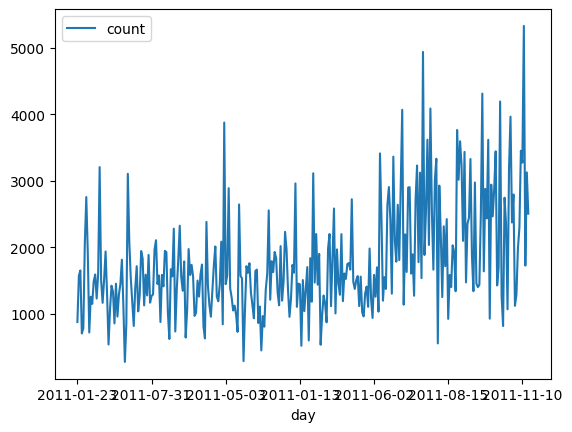

In [ ]:
retail_pd.plot(x="day",y="count",kind="line")

In [ ]:
retail_pd.sort_values(by='day', ascending = False, inplace = True)

In [ ]:
retail_pd

,day,count
222,2011-12-09,1632
233,2011-12-08,4940
276,2011-12-07,2438
213,2011-12-06,3365
301,2011-12-05,5331
...,...,...
99,2010-12-06,3878
185,2010-12-05,2725
161,2010-12-03,2202
53,2010-12-02,2109


In [ ]:
import plotly.express as px

fig = px.line(retail_pd, x='day', y='count')
fig.show()

In [ ]:
from pyspark.sql.functions import date_format

(
    retail_df_v2
    .groupBy("Country")
    .count()
    .show(10)
)

+------------------+-----+
|           Country|count|
+------------------+-----+
|            Sweden|  462|
|         Singapore|  229|
|           Germany| 9495|
|            France| 8557|
|            Greece|  146|
|European Community|   61|
|           Belgium| 2069|
|           Finland|  695|
|             Malta|  127|
|       Unspecified|  446|
+------------------+-----+
only showing top 10 rows



In [ ]:
retail_country_pd = (
    retail_df_v2
    .groupBy("Country")
    .count()
    .toPandas()
)

In [ ]:
retail_country_pd.head()

,Country,count
0,Sweden,462
1,Singapore,229
2,Germany,9495
3,France,8557
4,Greece,146


In [ ]:
# Plot a pie chart
fig = px.bar(retail_country_pd, y="count", x="Country")
fig.show()

In [ ]:
# Diluar UK, mana ya negara lain yang cukup tinggi

# Plot a pie chart
fig = px.bar(retail_country_pd[retail_country_pd['Country'] != 'United Kingdom'], y="count", x="Country")
fig.show()

In [ ]:
# Estimasi tokonya buka jam berapa ?
retail_pd_hour = (
    retail_df_v2
    .groupBy(date_format("InvoiceDate", "H").alias("hour"))
    .count()
    .toPandas()
)

In [ ]:
retail_pd_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   hour    15 non-null     object
 1   count   15 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 372.0+ bytes


In [ ]:
retail_pd_hour["hour"] = retail_pd_hour["hour"].astype(int)
retail_pd_hour.sort_values(by='hour', ascending = True, inplace = True)

In [ ]:
# kalo tutup jam berapa ?
fig = px.bar(retail_pd_hour, y="count", x="hour")
fig.show()

In [ ]:
# Customer paling banyak belanja berapa ? (Dollar & Quantity)
from pyspark.sql.functions import col, sum, round

(
    retail_df_v2
 .withColumn("TotalPrice",col("UnitPrice")*col("Quantity"))
 .groupBy("InvoiceNo","CustomerID")
 .agg(sum('TotalPrice').alias("FullPrice"))
 .withColumn("FullPrice", round("FullPrice",2))
 .orderBy("FullPrice",ascending=False)
 .show(5)
)

+---------+----------+---------+
|InvoiceNo|CustomerID|FullPrice|
+---------+----------+---------+
|   581483|     16446| 168469.6|
|   541431|     12346|  77183.6|
|   574941|      NULL| 52940.94|
|   576365|      NULL| 50653.91|
|   556444|     15098|  38970.0|
+---------+----------+---------+
only showing top 5 rows



In [ ]:
#Part 5 ends here

#Misc

In [ ]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(4040)"))

https://4040-m-s-3hpzdfhls4qin-b.us-east1-0.prod.colab.dev


In [ ]:
# Import SparkSession
from pyspark.sql import SparkSession
# Create a Spark Session
spark = SparkSession.builder.master("local[*]").getOrCreate()
# Check Spark Session Information
spark